In [7]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request

W0000 00:00:1779914629.939000 2504366 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1779914630.055693 2504366 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 88), renderer: Apple M2
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1779914630.064715 2504370 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1779914630.077749 2504370 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


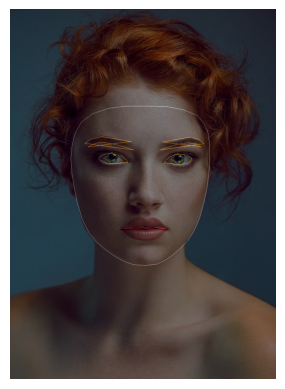

In [8]:
# Download the model file (only needed once)
urllib.request.urlretrieve(
    "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
    "face_landmarker.task"
)

FACEMESH_FACE_OVAL = frozenset([
    (10,338),(338,297),(297,332),(332,284),(284,251),(251,389),(389,356),
    (356,454),(454,323),(323,361),(361,288),(288,397),(397,365),(365,379),
    (379,378),(378,400),(400,377),(377,152),(152,148),(148,176),(176,149),
    (149,150),(150,136),(136,172),(172,58),(58,132),(132,93),(93,234),
    (234,127),(127,162),(162,21),(21,54),(54,103),(103,67),(67,109),(109,10)
])
FACEMESH_LEFT_EYE = frozenset([
    (263,249),(249,390),(390,373),(373,374),(374,380),(380,381),(381,382),
    (382,362),(362,398),(398,384),(384,385),(385,386),(386,387),(387,388),
    (388,466),(466,263)
])
FACEMESH_RIGHT_EYE = frozenset([
    (33,7),(7,163),(163,144),(144,145),(145,153),(153,154),(154,155),
    (155,133),(133,173),(173,157),(157,158),(158,159),(159,160),(160,161),
    (161,246),(246,33)
])
FACEMESH_LEFT_EYEBROW = frozenset([
    (276,283),(283,282),(282,295),(295,285),(285,300),(300,293),(293,334),
    (334,296),(296,336),(336,276)
])
FACEMESH_RIGHT_EYEBROW = frozenset([
    (46,53),(53,52),(52,65),(65,55),(55,70),(70,63),(63,105),(105,66),
    (66,107),(107,46)
])
FACEMESH_LIPS = frozenset([
    (61,146),(146,91),(91,181),(181,84),(84,17),(17,314),(314,405),(405,321),
    (321,375),(375,291),(291,409),(409,270),(270,269),(269,267),(267,0),
    (0,37),(37,39),(39,40),(40,185),(185,61),
    (78,95),(95,88),(88,178),(178,87),(87,14),(14,317),(317,402),(402,318),
    (318,324),(324,308),(308,415),(415,310),(310,311),(311,312),(312,13),
    (13,82),(82,81),(81,80),(80,191),(191,78)
])
FACEMESH_LEFT_IRIS = frozenset([
    (474,475),(475,476),(476,477),(477,474)
])
FACEMESH_RIGHT_IRIS = frozenset([
    (469,470),(470,471),(471,472),(472,469)
])

FEATURES = {
    "face_oval":     FACEMESH_FACE_OVAL,
    "left_eye":      FACEMESH_LEFT_EYE,
    "right_eye":     FACEMESH_RIGHT_EYE,
    "left_eyebrow":  FACEMESH_LEFT_EYEBROW,
    "right_eyebrow": FACEMESH_RIGHT_EYEBROW,
    "lips":          FACEMESH_LIPS,
    "left_iris":     FACEMESH_LEFT_IRIS,
    "right_iris":    FACEMESH_RIGHT_IRIS,
}

COLORS = {
    "face_oval":     (180, 180, 180),
    "left_eye":      (0, 200, 255),
    "right_eye":     (0, 200, 255),
    "left_eyebrow":  (0, 160, 255),
    "right_eyebrow": (0, 160, 255),
    "lips":          (60, 60, 255),
    "left_iris":     (0, 255, 180),
    "right_iris":    (0, 255, 180),
}

def order_points_from_connections(connections):
    """Walk the edge graph to produce an ordered list of landmark indices."""
    # Build adjacency map
    adj = {}
    for a, b in connections:
        adj.setdefault(a, []).append(b)
        adj.setdefault(b, []).append(a)

    # Start from any node and walk
    start = next(iter(adj))
    ordered = [start]
    visited = {start}

    current = start
    while True:
        neighbors = [n for n in adj[current] if n not in visited]
        if not neighbors:
            break
        current = neighbors[0]
        ordered.append(current)
        visited.add(current)

    return ordered

def draw_feature_exact(canvas, landmarks, connections, color, h, w):
    ordered_indices = order_points_from_connections(connections)

    pts = []
    for i in ordered_indices:
        lm = landmarks[i]
        pts.append((int(lm.x * w), int(lm.y * h)))

    pts = np.array(pts, dtype=np.int32)
    cv2.polylines(canvas, [pts], isClosed=True, color=color, thickness=1)

# Load image
img = cv2.imread("sample_images/portrait1.jpg")
h, w = img.shape[:2]
canvas = np.zeros_like(img)

# Run landmarker
base_options = python.BaseOptions(model_asset_path="face_landmarker.task")
options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    min_face_detection_confidence=0.5
)

with vision.FaceLandmarker.create_from_options(options) as landmarker:
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    result = landmarker.detect(mp_image)

    if result.face_landmarks:
        landmarks = result.face_landmarks[0]
        for feature, connections in FEATURES.items():
            draw_feature_exact(canvas, landmarks, connections, COLORS[feature], h, w)

plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), alpha=0.5)  # Show original image with some transparency
plt.axis('off')
plt.show()